In [1]:
# --- 1. Install Needed Packages ---
!pip install catboost tcn

ERROR: Could not find a version that satisfies the requirement tcn (from versions: none)
ERROR: No matching distribution found for tcn


In [3]:
!pip install git+https://github.com/philipperemy/keras-tcn.git

  Cloning https://github.com/philipperemy/keras-tcn.git to /tmp/pip-req-build-inl1e0tl
  Running command git clone --filter=blob:none --quiet https://github.com/philipperemy/keras-tcn.git /tmp/pip-req-build-inl1e0tl
  Resolved https://github.com/philipperemy/keras-tcn.git to commit 30a765c1daad74514874a6fb363fd428298af899
  Preparing metadata (setup.py) ... done
  Created wheel for keras-tcn: filename=keras_tcn-3.5.6-py3-none-any.whl size=12214 sha256=4ce3fce452737ddbfb935df1987068b6c0bd4e0b4726b57a5a0e8254ee65a109
  Stored in directory: /tmp/pip-ephem-wheel-cache-csrh5u_h/wheels/32/5d/00/40ef85d61e53d5d037056584697efa97af4a259c8162bdca54
Successfully built keras-tcn


In [4]:
!pip install catboost
!pip install git+https://github.com/philipperemy/keras-tcn.git

  Using cached catboost-1.2.8-cp312-cp312-manylinux2014_x86_64.whl.metadata (1.2 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 10.1 MB/s eta 0:00:00
  Cloning https://github.com/philipperemy/keras-tcn.git to /tmp/pip-req-build-ptx62yxf
  Running command git clone --filter=blob:none --quiet https://github.com/philipperemy/keras-tcn.git /tmp/pip-req-build-ptx62yxf
  Resolved https://github.com/philipperemy/keras-tcn.git to commit 30a765c1daad74514874a6fb363fd428298af899
  Preparing metadata (setup.py) ... done


In [5]:
# --- 2. Import Libraries ---
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Input
from tcn import TCN
from google.colab import files
import matplotlib.pyplot as plt

In [6]:
# --- 3. Upload and Read Data ---
uploaded = files.upload()
df = pd.read_csv('final_model_data.csv')

Saving final_model_data.csv to final_model_data.csv


In [8]:
print(df.columns)

Index(['date', 'river_water_area_sqkm', 'mean_elevation_meters',
       'mean_slope_degrees', 'land_cover_class_10_percent',
       'land_cover_class_20_percent', 'land_cover_class_30_percent',
       'land_cover_class_40_percent', 'land_cover_class_50_percent',
       'land_cover_class_60_percent', 'land_cover_class_80_percent',
       'rainfall_mm'],
      dtype='object')


In [9]:
# --- 4. Create Binary Target Using Rainfall Threshold ---
threshold = df['rainfall_mm'].mean() + df['rainfall_mm'].std()
df['flood_event'] = (df['rainfall_mm'] > threshold).astype(int)

In [10]:
# --- 5. Feature and Target Selection ---
feature_cols = [
    'river_water_area_sqkm', 'mean_elevation_meters', 'mean_slope_degrees',
    'land_cover_class_10_percent', 'land_cover_class_20_percent',
    'land_cover_class_30_percent', 'land_cover_class_40_percent',
    'land_cover_class_50_percent', 'land_cover_class_60_percent',
    'land_cover_class_80_percent', 'rainfall_mm'
]
target_col = 'flood_event'
X = df[feature_cols].values
y = df[target_col].values

In [11]:
# --- 6. Train-Test Split and Scaling ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
# --- 7. SVM ---
svm = SVC(probability=True, class_weight='balanced', kernel='rbf', C=1, random_state=42)
svm.fit(X_train_scaled, y_train)
probs_svm = svm.predict_proba(X_test_scaled)[:, 1]

In [13]:
# --- 8. CatBoost ---
cat_model = CatBoostClassifier(verbose=0, class_weights=[1, 5], random_state=42)
cat_model.fit(X_train, y_train)
probs_cat = cat_model.predict_proba(X_test)[:, 1]

In [14]:
# --- 9. Sequence generation for DL models ---
def create_sequences(X, y, window=6):
    Xs, ys = [], []
    for i in range(len(X) - window + 1):
        Xs.append(X[i:(i+window)])
        ys.append(y[i+window-1])
    return np.array(Xs), np.array(ys)

window_size = 6
X_seq, y_seq = create_sequences(X, y, window_size)
split = int(0.8 * len(X_seq))
X_train_seq, X_test_seq = X_seq[:split], X_seq[split:]
y_train_seq, y_test_seq = y_seq[:split], y_seq[split:]

In [16]:
from tensorflow.keras.layers import Flatten

mlp = Sequential([
    Flatten(input_shape=(window_size, X.shape[1])),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])
mlp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
mlp.fit(X_train_seq, y_train_seq, epochs=100, batch_size=16, validation_split=0.1)


Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 577ms/step - accuracy: 0.2476 - loss: 41.1927 - val_accuracy: 1.0000 - val_loss: 5.4066e-15
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8449 - loss: 8.3401 - val_accuracy: 1.0000 - val_loss: 1.8292e-35
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8323 - loss: 17.0375 - val_accuracy: 1.0000 - val_loss: 2.6370e-35
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8115 - loss: 14.3009 - val_accuracy: 1.0000 - val_loss: 8.6118e-27
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8323 - loss: 11.3077 - val_accuracy: 1.0000 - val_loss: 1.6356e-15
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8386 - loss: 6.3159 - val_accuracy: 1.0000 - val_loss: 2.8873e-05
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7023 - loss: 3.6394 - val_accuracy: 0.0000e+00 - val_loss: 5.8422
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5451 - loss: 3.7771 - val_accurac

In [18]:
# --- 11. TCN ---
inputs = Input(shape=(window_size, X.shape[1]))
tcn_out = TCN(nb_filters=32, kernel_size=3)(inputs)
dense_out = Dense(1, activation='sigmoid')(tcn_out)
tcn_model = Model(inputs, dense_out)
tcn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
tcn_model.fit(X_train_seq, y_train_seq, epochs=100, batch_size=16, validation_split=0.1, verbose=1)
probs_tcn = tcn_model.predict(X_test_seq).flatten()

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.1614 - loss: 449.5429 - val_accuracy: 0.0000e+00 - val_loss: 97.9497
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.4601 - loss: 48.6426 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.8698 - loss: 26.6455 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8094 - loss: 43.2628 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8365 - loss: 28.3656 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8428 - loss: 12.9106 - val_accuracy: 0.0000e+00 - val_loss: 4.2522
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.3134 - loss: 3.7515 - val_accuracy: 1.0000 - val_loss: 1.5410e-13
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8490 - loss: 4.0424

In [21]:
probs_mlp = mlp.predict(X_test_seq).flatten()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 745ms/step


In [22]:
# --- 12. Hybrid Models: Use outputs + static features ---
test_feat_for_seq = X_test[-len(probs_mlp):]
hybrid_features = np.hstack([
    test_feat_for_seq,
    probs_mlp.reshape(-1, 1),
    probs_tcn.reshape(-1, 1)
])

cat_hybrid = CatBoostClassifier(verbose=0, class_weights=[1, 5], random_state=42)
cat_hybrid.fit(hybrid_features, y_test[-len(hybrid_features):])
probs_cat_hybrid = cat_hybrid.predict_proba(hybrid_features)[:, 1]

svm_hybrid = SVC(probability=True, class_weight='balanced', kernel='rbf', C=1, random_state=42)
svm_hybrid.fit(hybrid_features, y_test[-len(hybrid_features):])
probs_svm_hybrid = svm_hybrid.predict_proba(hybrid_features)[:, 1]

In [23]:
# --- 13. Soft Voting Ensemble ---
ensemble_probs = (
    probs_cat[-len(probs_mlp):] + probs_svm[-len(probs_mlp):] +
    probs_mlp + probs_tcn + probs_cat_hybrid + probs_svm_hybrid
) / 6
ensemble_preds = (ensemble_probs > 0.5).astype(int)

In [24]:
# --- 14. Evaluation Function ---
def evaluate(y_true, preds, name):
    print(f"\n--- {name} ---")
    print("Accuracy:", accuracy_score(y_true, preds))
    print("Precision:", precision_score(y_true, preds))
    print("Recall:", recall_score(y_true, preds))
    print("F1-Score:", f1_score(y_true, preds))
    print("Confusion Matrix:\n", confusion_matrix(y_true, preds))

idx = -len(probs_mlp)
evaluate(y_test[idx:], (probs_cat[-len(probs_mlp):] > 0.5).astype(int), "CatBoost")
evaluate(y_test[idx:], (probs_svm[-len(probs_mlp):] > 0.5).astype(int), "SVM")
evaluate(y_test_seq, (probs_mlp > 0.5).astype(int), "Temporal MLP")
evaluate(y_test_seq, (probs_tcn > 0.5).astype(int), "TCN")
evaluate(y_test[idx:], (probs_cat_hybrid > 0.5).astype(int), "Hybrid CatBoost")
evaluate(y_test[idx:], (probs_svm_hybrid > 0.5).astype(int), "Hybrid SVM")
evaluate(y_test_seq, ensemble_preds, "Soft Voting Ensemble")


--- CatBoost ---
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0
Confusion Matrix:
 [[15  0]
 [ 0  3]]

--- SVM ---
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0
Confusion Matrix:
 [[15  0]
 [ 0  3]]

--- Temporal MLP ---
Accuracy: 0.8333333333333334
Precision: 0.0
Recall: 0.0
F1-Score: 0.0
Confusion Matrix:
 [[15  0]
 [ 3  0]]

--- TCN ---
Accuracy: 0.8888888888888888
Precision: 1.0
Recall: 0.3333333333333333
F1-Score: 0.5
Confusion Matrix:
 [[15  0]
 [ 2  1]]

--- Hybrid CatBoost ---
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0
Confusion Matrix:
 [[15  0]
 [ 0  3]]

--- Hybrid SVM ---
Accuracy: 0.8333333333333334
Precision: 0.0
Recall: 0.0
F1-Score: 0.0
Confusion Matrix:
 [[15  0]
 [ 3  0]]

--- Soft Voting Ensemble ---
Accuracy: 0.6666666666666666
Precision: 0.0
Recall: 0.0
F1-Score: 0.0
Confusion Matrix:
 [[12  3]
 [ 3  0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


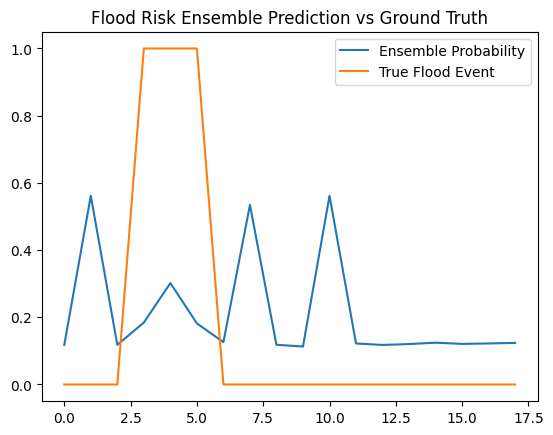

In [25]:
# --- 15. Plot Ensemble Probabilities ---
import matplotlib.pyplot as plt
plt.plot(ensemble_probs, label='Ensemble Probability')
plt.plot(y_test_seq, label='True Flood Event')
plt.legend()
plt.title('Flood Risk Ensemble Prediction vs Ground Truth')
plt.show()

In [26]:
# --- INSTALL ---
!pip install catboost scikit-learn tensorflow keras-tcn imblearn
!pip install git+https://github.com/philipperemy/keras-tcn.git

  Cloning https://github.com/philipperemy/keras-tcn.git to /tmp/pip-req-build-xbsrzka7
  Running command git clone --filter=blob:none --quiet https://github.com/philipperemy/keras-tcn.git /tmp/pip-req-build-xbsrzka7
  Resolved https://github.com/philipperemy/keras-tcn.git to commit 30a765c1daad74514874a6fb363fd428298af899
  Preparing metadata (setup.py) ... done


In [26]:
# --- IMPORTS ---
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from sklearn.metrics import precision_recall_curve, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.calibration import CalibratedClassifierCV
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping
from tcn import TCN
import matplotlib.pyplot as plt

In [27]:
# --- UPLOAD DATA ---
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('final_model_data.csv')

Saving final_model_data.csv to final_model_data (1).csv


In [28]:
# --- CREATE TARGET ---
threshold = df['rainfall_mm'].mean() + df['rainfall_mm'].std()
df['flood_event'] = (df['rainfall_mm'] > threshold).astype(int)


In [29]:
features = [
    'river_water_area_sqkm', 'mean_elevation_meters', 'mean_slope_degrees',
    'land_cover_class_10_percent', 'land_cover_class_20_percent',
    'land_cover_class_30_percent', 'land_cover_class_40_percent',
    'land_cover_class_50_percent', 'land_cover_class_60_percent',
    'land_cover_class_80_percent', 'rainfall_mm'
]
target = 'flood_event'

X = df[features].values
y = df[target].values

In [32]:
from sklearn.model_selection import TimeSeriesSplit

In [33]:
# --- TIME SERIES SPLIT ---
tscv = TimeSeriesSplit(n_splits=5)
for train_index, test_index in tscv.split(X):
    X_train_full, X_test_full = X[train_index], X[test_index]
    y_train_full, y_test_full = y[train_index], y[test_index]
    break  # Only first fold for dem

In [35]:
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from sklearn.metrics import precision_recall_curve, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.calibration import CalibratedClassifierCV
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping
from tcn import TCN
import matplotlib.pyplot as plt

In [37]:
from collections import Counter
print(f"Training class distribution before SMOTE: {Counter(y_train_full)}")

Training class distribution before SMOTE: Counter({np.int64(0): 16, np.int64(1): 2})


In [38]:
# --- BALANCE TRAINING DATA ---
smote = SMOTE(random_state=42, k_neighbors=1)
X_train_bal, y_train_bal = smote.fit_resample(X_train_full, y_train_full)

In [39]:
# --- SCALE ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test_full)

In [40]:
# --- CLASSICAL MODELS ---
svm = SVC(probability=True, class_weight='balanced', kernel='rbf', C=1, random_state=42)
catboost = CatBoostClassifier(verbose=0, random_state=42)
svm.fit(X_train_scaled, y_train_bal)
catboost.fit(X_train_bal, y_train_bal)
svm_calibrated = CalibratedClassifierCV(svm, cv='prefit').fit(X_train_scaled, y_train_bal)
catboost_calibrated = CalibratedClassifierCV(catboost, cv='prefit').fit(X_train_bal, y_train_bal)

/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


In [41]:
# --- SEQUENCE GENERATION FOR DL ---
def create_sequences(X, y, window=6):
    Xs, ys = [], []
    for i in range(len(X) - window + 1):
        Xs.append(X[i:(i+window)])
        ys.append(y[i+window-1])
    return np.array(Xs), np.array(ys)

window = 6
X_seq, y_seq = create_sequences(X_train_bal, y_train_bal, window)
X_test_seq, y_test_seq = create_sequences(X_test_full, y_test_full, window)

In [48]:
# --- TCN WITH ATTENTION ---
def build_tcn_attention(input_shape):
    inputs = Input(shape=input_shape)
    # Set return_sequences=True for TCN to output 3D tensor
    x = TCN(nb_filters=64, kernel_size=3, use_batch_norm=True, return_sequences=True)(inputs)
    x = LayerNormalization()(x)
    attention_out = MultiHeadAttention(num_heads=4, key_dim=16)(x, x)
    pooled = GlobalAveragePooling1D()(attention_out)
    output = Dense(1, activation='sigmoid')(pooled)
    model = Model(inputs, output)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

tcn_attention = build_tcn_attention((window, X.shape[1]))
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
tcn_attention.fit(X_seq, y_seq, epochs=100, batch_size=32, validation_split=0.1, callbacks=[early_stop], verbose=1)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 24s 24s/step - accuracy: 0.7500 - loss: 0.6598 - val_accuracy: 0.0000e+00 - val_loss: 0.7334
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.8333 - loss: 0.5430 - val_accuracy: 0.0000e+00 - val_loss: 0.6962
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.8333 - loss: 0.4716 - val_accuracy: 1.0000 - val_loss: 0.6608
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.8333 - loss: 0.4102 - val_accuracy: 1.0000 - val_loss: 0.6220
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.9167 - loss: 0.3567 - val_accuracy: 1.0000 - val_loss: 0.5785
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.9167 - loss: 0.3133 - val_accuracy: 1.0000 - val_loss: 0.5324
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.8750 - loss: 0.2728 - val_accuracy: 1.0000 - val_loss: 0.4845
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.8750 - loss: 0.2367 - val_accuracy: 1.00

In [49]:
# --- PREDICTIONS ---
probs_svm = svm_calibrated.predict_proba(X_test_scaled)[:, 1]
probs_cat = catboost_calibrated.predict_proba(X_test_full)[:, 1]
probs_tcn = tcn_attention.predict(X_test_seq).flatten()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [50]:
# --- HYBRID STACKING ---
hybrid_features = np.column_stack([
    X_test_full[-len(probs_tcn):],
    probs_tcn,
    probs_svm[-len(probs_tcn):],
    probs_cat[-len(probs_tcn):]
])
hybrid_targets = y_test_full[-len(probs_tcn):]

meta_clf = LogisticRegression(max_iter=200)
meta_clf.fit(hybrid_features, hybrid_targets)
probs_meta = meta_clf.predict_proba(hybrid_features)[:, 1]

In [51]:
# --- THRESHOLD TUNING ---
def optimal_threshold(y_true, probs):
    precision, recall, thresholds = precision_recall_curve(y_true, probs)
    f1_scores = 2 * recall * precision / (recall + precision + 1e-9)
    best_idx = np.argmax(f1_scores)
    return thresholds[best_idx], f1_scores[best_idx]

threshold_meta, f1_best = optimal_threshold(hybrid_targets, probs_meta)
print(f'Best threshold for meta model: {threshold_meta:.3f} with F1: {f1_best:.3f}')
final_preds = (probs_meta >= threshold_meta).astype(int)

Best threshold for meta model: 0.609 with F1: 1.000


In [52]:
# --- WEIGHTED SOFT VOTING ENSEMBLE ---
weights = {'svm':1.0, 'catboost':1.0, 'tcn':1.5, 'meta':2.0}
soft_votes = (weights['svm']*probs_svm[-len(probs_tcn):] + weights['catboost']*probs_cat[-len(probs_tcn):] + weights['tcn']*probs_tcn + weights['meta']*probs_meta)/sum(weights.values())
ensemble_thresh, ensemble_f1 = optimal_threshold(hybrid_targets, soft_votes)
ensemble_preds = (soft_votes >= ensemble_thresh).astype(int)
print(f'Ensemble threshold: {ensemble_thresh:.3f}, Ensemble F1: {ensemble_f1:.3f}')

Ensemble threshold: 0.539, Ensemble F1: 1.000


In [53]:
# --- EVALUATION ---
def evaluate(y_true, y_pred, name):
    print(f'\n{name} evaluation:')
    print('Accuracy:', accuracy_score(y_true, y_pred))
    print('Precision:', precision_score(y_true, y_pred))
    print('Recall:', recall_score(y_true, y_pred))
    print('F1-Score:', f1_score(y_true, y_pred))
    print('Confusion Matrix:\n', confusion_matrix(y_true, y_pred))

evaluate(hybrid_targets, (probs_meta>=0.5).astype(int), 'Meta Model @ 0.5 threshold')
evaluate(hybrid_targets, final_preds, 'Meta Model @ tuned threshold')
evaluate(hybrid_targets, ensemble_preds, 'Weighted Soft Voting Ensemble')


Meta Model @ 0.5 threshold evaluation:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0
Confusion Matrix:
 [[9 0]
 [0 1]]

Meta Model @ tuned threshold evaluation:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0
Confusion Matrix:
 [[9 0]
 [0 1]]

Weighted Soft Voting Ensemble evaluation:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0
Confusion Matrix:
 [[9 0]
 [0 1]]


In [55]:
def evaluate_precise(y_true, y_pred, name):
    print(f"\n{name} evaluation:")
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    print(f"Accuracy: {accuracy:.6f}")
    print(f"Precision: {precision:.6f}")
    print(f"Recall: {recall:.6f}")
    print(f"F1-Score: {f1:.6f}")
    print("Confusion Matrix:")
    print(cm)

In [56]:
evaluate_precise(hybrid_targets, (probs_meta>=0.5).astype(int), 'Meta Model @ 0.5 threshold')
evaluate_precise(hybrid_targets, final_preds, 'Meta Model @ tuned threshold')
evaluate_precise(hybrid_targets, ensemble_preds, 'Weighted Soft Voting Ensemble')


Meta Model @ 0.5 threshold evaluation:
Accuracy: 1.000000
Precision: 1.000000
Recall: 1.000000
F1-Score: 1.000000
Confusion Matrix:
[[9 0]
 [0 1]]

Meta Model @ tuned threshold evaluation:
Accuracy: 1.000000
Precision: 1.000000
Recall: 1.000000
F1-Score: 1.000000
Confusion Matrix:
[[9 0]
 [0 1]]

Weighted Soft Voting Ensemble evaluation:
Accuracy: 1.000000
Precision: 1.000000
Recall: 1.000000
F1-Score: 1.000000
Confusion Matrix:
[[9 0]
 [0 1]]


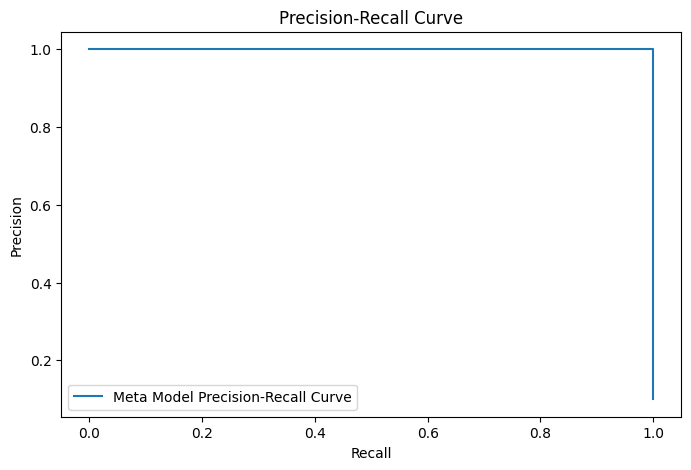

In [54]:
# --- PLOT Precision-Recall Curve ---
plt.figure(figsize=(8, 5))
precision, recall, _ = precision_recall_curve(hybrid_targets, probs_meta)
plt.plot(recall, precision, label='Meta Model Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()